In [ ]:
#Step 1 — Install KaggleHub
!pip install -q kagglehub

In [ ]:
#Step 2 — Import Libraries
import pandas as pd
import numpy as np
import os
import re

import matplotlib.pyplot as plt

In [ ]:
#ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
#Step 3 — Download General Sentiment Dataset
import kagglehub

dataset_path = kagglehub.dataset_download(
    "kazanova/sentiment140"
)

print("Dataset downloaded at:")
print(dataset_path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Dataset downloaded at:
/kaggle/input/sentiment140


In [ ]:
#Step 4 — Dataset ke andar kya files hain?
print(os.listdir(dataset_path))

['training.1600000.processed.noemoticon.csv']


In [ ]:
#Step 5 — CSV File Automatically Find Karo
csv_files = []

for root, folders, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(
                os.path.join(root, file)
            )

print(csv_files)

['/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv']


In [ ]:
#Step 6 — Dataset Load Karo
file_path = csv_files[0]

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None
)

In [ ]:
#Step 7 — Columns ke Names Set Karo
df.columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "text"
]

In [ ]:
#Step 8 — Dataset Check
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1600000
Columns: 6


In [ ]:
df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
#Step 9 — Sirf Required Columns Rakho
df = df[
    ["text", "sentiment"]
]

In [ ]:
df.head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [ ]:
#Step 10 — Sentiment Values Check Karo
print(
    df["sentiment"].value_counts()
)

sentiment
0    800000
4    800000
Name: count, dtype: int64


In [ ]:
#Step 11 — Positive / Negative Mapping
df["sentiment"] = df["sentiment"].map({
    0: "Negative",
    4: "Positive"
})

In [ ]:
df.head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative
1,is upset that he can't update his Facebook by ...,Negative
2,@Kenichan I dived many times for the ball. Man...,Negative
3,my whole body feels itchy and like its on fire,Negative
4,"@nationwideclass no, it's not behaving at all....",Negative


In [ ]:
#Step 12 — Missing Values Check
print(
    df.isnull().sum()
)

text         0
sentiment    0
dtype: int64


In [ ]:
#Step 13 — Missing Rows Remove
df = df.dropna()

In [ ]:
#Step 14 — Duplicate Text Remove
df = df.drop_duplicates(
    subset="text"
)

In [ ]:
print(df.shape)

(1581466, 2)


In [ ]:
#Step 15 — Sentiment Distribution
print(
    df["sentiment"].value_counts()
)

sentiment
Positive    791281
Negative    790185
Name: count, dtype: int64


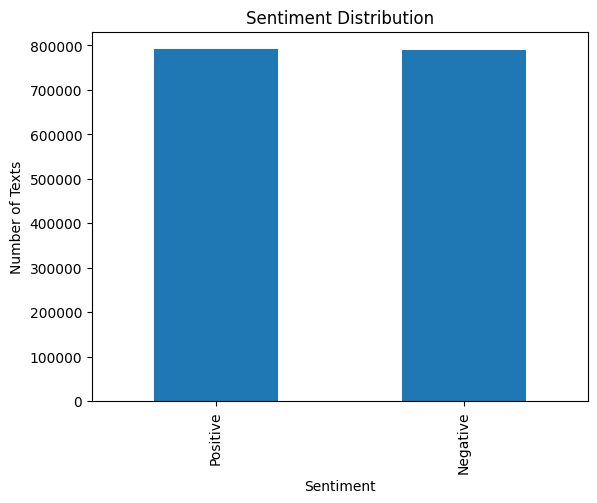

In [ ]:
df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")

plt.show()

In [ ]:
#Step 16 — Text Cleaning Function
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    text = re.sub(
        r"@\w+",
        "",
        text
    )

    text = re.sub(
        r"#\w+",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [ ]:
#Step 17 — Test Cleaning
sample = df["text"].iloc[0]

print("Original:")
print(sample)

print("\nCleaned:")
print(clean_text(sample))

Original:
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Cleaned:
a that s a bummer you shoulda got david carr of third day to do it d


In [ ]:
#Step 18 — Apply Cleaning
df["clean_text"] = df["text"].apply(
    clean_text
)

In [ ]:
df[
    ["text", "clean_text"]
].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",a that s a bummer you shoulda got david carr o...
1,is upset that he can't update his Facebook by ...,is upset that he can t update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it s not behaving at all i m mad why am i h...


In [ ]:
#Step 19 — Remove Empty Text
df = df[
    df["clean_text"].str.len() > 0
]

In [ ]:
#Step 20 — X and y
X = df["clean_text"]

y = df["sentiment"]

In [ ]:
#Step 21 — Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#Step 22 — Check Data Size
print(
    "Training data:",
    len(X_train)
)

print(
    "Testing data:",
    len(X_test)
)

Training data: 1262150
Testing data: 315538


In [ ]:
#Step 23 — TF-IDF
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2)
)

In [ ]:
#Step 24 — Training Text ko TF-IDF mein Convert Karo
X_train_tfidf = tfidf.fit_transform(
    X_train
)

In [ ]:
#Step 25 — Testing Text Convert Karo
X_test_tfidf = tfidf.transform(
    X_test
)

In [ ]:
#Step 26 — Shape Check
print(
    "Training shape:",
    X_train_tfidf.shape
)

print(
    "Testing shape:",
    X_test_tfidf.shape
)

Training shape: (1262150, 20000)
Testing shape: (315538, 20000)


In [ ]:
#Step 27 — Logistic Regression Model
model = LogisticRegression(
    max_iter=1000
)

In [ ]:
#Step 28 — Train Model
model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
#Step 29 — Prediction
y_pred = model.predict(
    X_test_tfidf
)

In [ ]:
#Step 30 — Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.7799567722429628


In [ ]:
print(
    "Accuracy:",
    accuracy * 100,
    "%"
)

Accuracy: 77.99567722429627 %


In [ ]:
#Step 31 — Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[119203  38504]
 [ 30928 126903]]


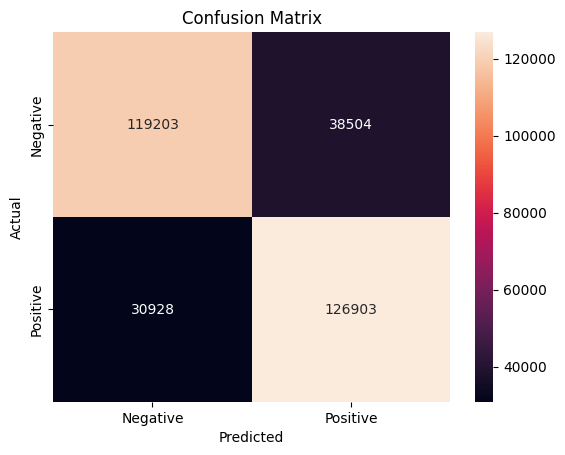

In [ ]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [ ]:
#Step 32 — Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.79      0.76      0.77    157707
    Positive       0.77      0.80      0.79    157831

    accuracy                           0.78    315538
   macro avg       0.78      0.78      0.78    315538
weighted avg       0.78      0.78      0.78    315538



In [ ]:
#Step 33 — Universal Prediction Function
def predict_sentiment(text):

    cleaned_text = clean_text(text)

    text_tfidf = tfidf.transform(
        [cleaned_text]
    )

    prediction = model.predict(
        text_tfidf
    )[0]

    probability = model.predict_proba(
        text_tfidf
    )[0]

    confidence = max(probability) * 100

    return prediction, confidence

In [ ]:
#Step 34 — Product Review Test
text = "The phone quality is amazing and the camera is excellent."

sentiment, confidence = predict_sentiment(
    text
)

print("Text:", text)
print("Sentiment:", sentiment)
print("Confidence:", round(confidence, 2), "%")

Text: The phone quality is amazing and the camera is excellent.
Sentiment: Positive
Confidence: 91.96 %


In [ ]:
#Step 35 — Food Review Test
text = "The food was delicious and the service was excellent."

sentiment, confidence = predict_sentiment(
    text
)

print("Text:", text)
print("Sentiment:", sentiment)
print("Confidence:", round(confidence, 2), "%")

Text: The food was delicious and the service was excellent.
Sentiment: Positive
Confidence: 90.99 %


In [ ]:
#Step 36 — Customer Service Test
text = "The customer support was terrible and nobody helped me."

sentiment, confidence = predict_sentiment(
    text
)

print("Text:", text)
print("Sentiment:", sentiment)
print("Confidence:", round(confidence, 2), "%")

Text: The customer support was terrible and nobody helped me.
Sentiment: Negative
Confidence: 68.38 %


In [ ]:
#Step 37 — Delivery Test
text = "My package arrived late and the box was damaged."

sentiment, confidence = predict_sentiment(
    text
)

print("Text:", text)
print("Sentiment:", sentiment)
print("Confidence:", round(confidence, 2), "%")

Text: My package arrived late and the box was damaged.
Sentiment: Negative
Confidence: 85.19 %


In [ ]:
#Step 38 — College Feedback Test
text = "The teachers are very supportive and the practical sessions are useful."

sentiment, confidence = predict_sentiment(
    text
)

print("Text:", text)
print("Sentiment:", sentiment)
print("Confidence:", round(confidence, 2), "%")

Text: The teachers are very supportive and the practical sessions are useful.
Sentiment: Positive
Confidence: 73.08 %


In [ ]:
#Step 39 — Negative Workplace Feedback
text = "The workload is too high and the management does not listen to employees."

sentiment, confidence = predict_sentiment(
    text
)

print("Text:", text)
print("Sentiment:", sentiment)
print("Confidence:", round(confidence, 2), "%")

Text: The workload is too high and the management does not listen to employees.
Sentiment: Positive
Confidence: 54.56 %


In [ ]:
#Step 40 — User Input
text = input(
    "Enter any text: "
)

sentiment, confidence = predict_sentiment(
    text
)

print(
    "\nPredicted Sentiment:",
    sentiment
)

print(
    "Confidence:",
    round(confidence, 2),
    "%"
)

Enter any text: food is good

Predicted Sentiment: Positive
Confidence: 69.9 %
